In [1]:
import sys

print("Python:", sys.executable)
print("Prefix:", sys.prefix)

Python: /workspaces/quant-pairs-trading/.venv/bin/python
Prefix: /workspaces/quant-pairs-trading/.venv


In [2]:
import pandas as pd

print("Pandas:", pd.__version__)

Pandas: 3.0.6


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv(
    "../data/raw/prices.csv",
    index_col=0,
    parse_dates=True,
)

prices.head()

,KO,PEP
Date,,
2018-01-02,34.816475,89.690910
2018-01-03,34.740017,89.455414
2018-01-04,35.229328,89.896042
2018-01-05,35.221661,90.154335
2018-01-08,35.168156,89.637733


In [4]:
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2202 entries, 2018-01-02 to 2026-10-06
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   KO      2202 non-null   float64
 1   PEP     2202 non-null   float64
dtypes: float64(2)
memory usage: 51.6 KB


In [5]:
prices.describe()

,KO,PEP
count,2202.000000,2202.000000
mean,52.479950,129.349700
std,13.181831,25.159397
min,30.918896,73.593246
25%,41.860407,109.475883
50%,52.716871,136.102135
75%,59.436882,150.484638
max,91.444336,173.550262


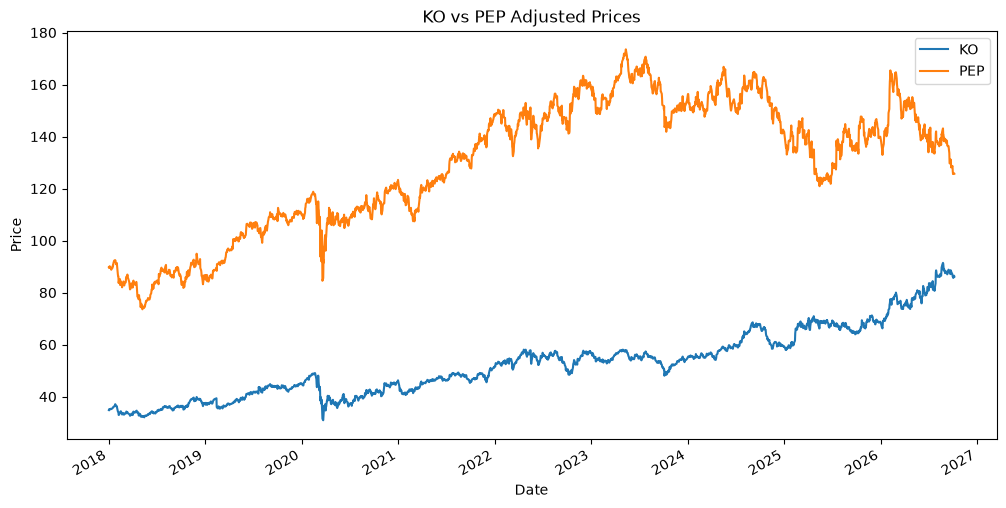

In [6]:
prices.plot(figsize=(12, 6))
plt.title("KO vs PEP Adjusted Prices")
plt.ylabel("Price")
plt.show()

1. Exploratory Data Analysis (EDA) Set-up

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#

prices = pd.read_csv(
    "../data/raw/prices.csv",
    index_col=0,
    parse_dates=True
)

prices = prices.dropna()

prices.head()

,KO,PEP
Date,,
2018-01-02,34.816475,89.690910
2018-01-03,34.740017,89.455414
2018-01-04,35.229328,89.896042
2018-01-05,35.221661,90.154335
2018-01-08,35.168156,89.637733


2. Check the Dataset : You want zero missing values after dropna()

In [8]:
print("Rows:", len(prices))
print("Columns:", list(prices.columns))
print("Date range:", prices.index.min(), "→", prices.index.max())
print("\nMissing values:")
print(prices.isna().sum())

Rows: 2202
Columns: ['KO', 'PEP']
Date range: 2018-01-02 00:00:00 → 2026-10-06 00:00:00

Missing values:
KO     0
PEP    0
dtype: int64


3. Plotting

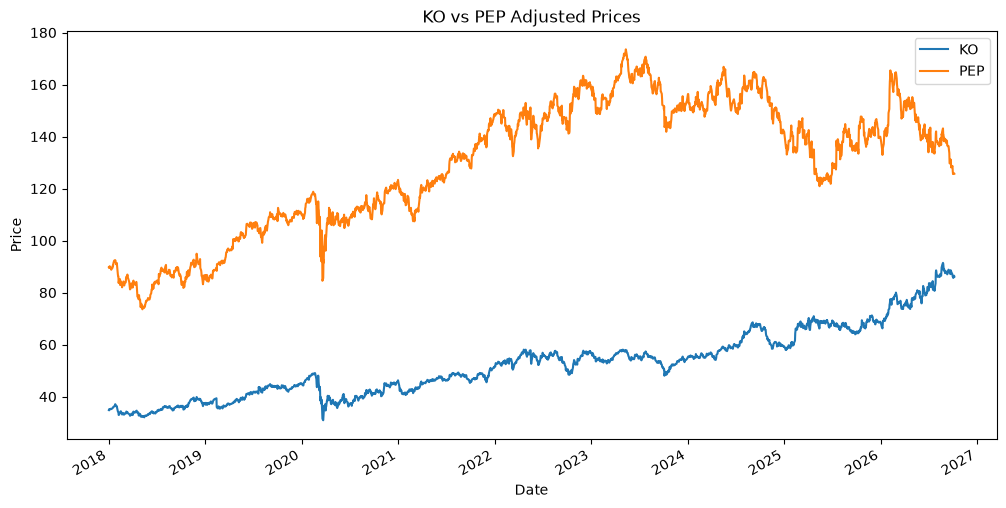

In [9]:
prices.plot(figsize=(12, 6))

plt.title("KO vs PEP Adjusted Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

4. Calculate log prices (to compare the 'relative movement')

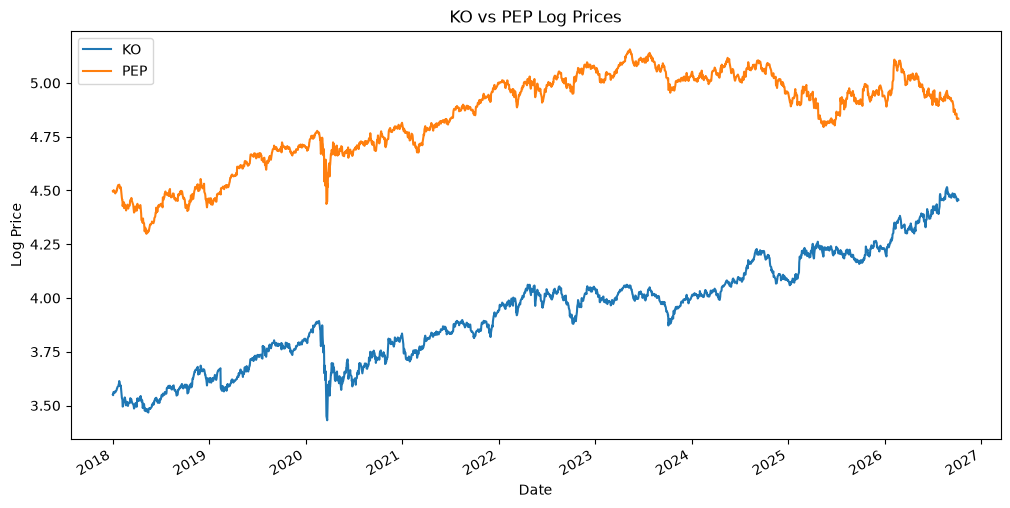

In [10]:
log_prices = np.log(prices)

log_prices.plot(figsize=(12, 6))

plt.title("KO vs PEP Log Prices")
plt.xlabel("Date")
plt.ylabel("Log Price")
plt.show()

Just looking at the graph, KO and PEP seem to share the similar move... 

5. Calulate correlation

In [11]:
returns = prices.pct_change().dropna()

correlation = returns["KO"].corr(returns["PEP"])

print(f"Return correlation: {correlation:.4f}")

Return correlation: 0.7070


.7 is SOMEWHAT IMPRESSIVE

6. Calculate basic return statistics 

In [ ]:
returns.describe()

,KO,PEP
count,2201.000000,2201.000000
mean,0.000486,0.000240
std,0.012166,0.013156
min,-0.096725,-0.114283
25%,-0.005383,-0.006016
50%,0.000637,0.000294
75%,0.006391,0.006747
max,0.064796,0.129366


In [14]:
#and 
annualized_volatility = returns.std() * np.sqrt(252)

print("Annualized volatility:")
print(annualized_volatility)

Annualized volatility:
KO     0.193137
PEP    0.208845
dtype: float64


7. Save the cleaned data

In [15]:
prices.to_csv("../data/processed/clean_prices.csv")
log_prices.to_csv("../data/processed/log_prices.csv")
returns.to_csv("../data/processed/returns.csv")

print("EDA data saved.")

EDA data saved.


At this point, we have...
data/
├── raw/
│   └── prices.csv
└── processed/
    ├── clean_prices.csv
    ├── log_prices.csv
    └── returns.csv